<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/CIFAR10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mastering the CIFAR-10 Bottleneck**

**Aim** : Build a robust computer vision pipeline to classify the **CIFAR-10** dataset. This exercise focuses on overcoming the specific challenges of low-resolution (*32x32*) imagery, high intra-class variance, and dataset noise.

In [1]:
# Importing libraries
import tensorflow as tf
from keras import layers, models
from keras.applications import ResNet50V2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Phase 1 : Data Pipeline Construction

###1.1 Loading and Exploring the Dataset

In [2]:
#loading cifar10 dataset from keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# checking for dataset shape
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


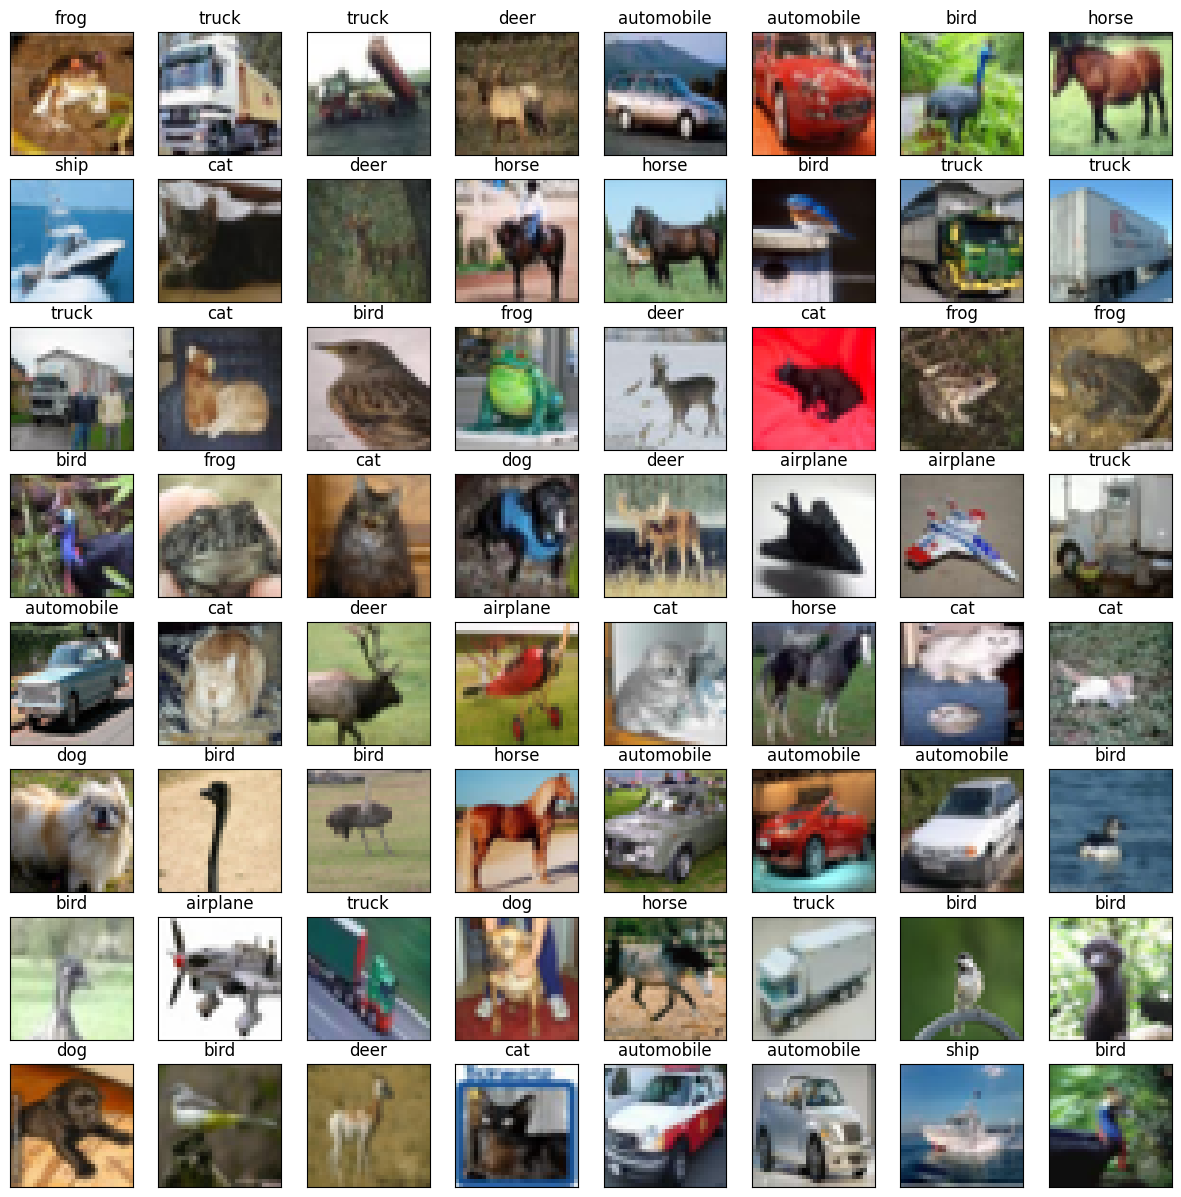

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualizing the Dataset
plt.figure(figsize=(15,15))

for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=12)
plt.show()

### 1.2 Applying Normalization
Standardize the RGB channels.

Useing mean=[0.4914, 0.4822, 0.4465] and std=[0.2470, 0.2435, 0.2616]

In [4]:
# Apply Normalization
mean = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
std = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)

x_train = (x_train.astype(np.float32) / 255.0 - mean) / std
x_test = (x_test.astype(np.float32) / 255.0 - mean) / std


### 1.3 Data Augmentation Pipeline

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.ZeroPadding2D(padding=4),
    layers.RandomCrop(height=32, width=32),
    layers.RandomFlip("horizontal"),
    layers.Resizing(32, 32)
], name="data_augmentation")

## Phase 2 : Architecture & Regularization
Design and instantiate two separate models for comparison:


### Model A: Strong Custom Baseline
A CNN with 5–8 convolutional layers.
> Includes BatchNorm, ReLU activations, and Dropout (0.3–0.5).


In [12]:
inputs_a = layers.Input(shape=(32, 32, 3))
x_a = data_augmentation(inputs_a)

# Block 1
x_a = layers.Conv2D(64, (3, 3), padding='same')(x_a)
x_a = layers.BatchNormalization()(x_a)
x_a = layers.Activation('relu')(x_a)
x_a = layers.Conv2D(64, (3, 3), padding='same')(x_a)
x_a = layers.BatchNormalization()(x_a)
x_a = layers.Activation('relu')(x_a)
x_a = layers.MaxPooling2D((2, 2))(x_a)
x_a = layers.Dropout(0.3)(x_a)

# Block 2
x_a = layers.Conv2D(128, (3, 3), padding='same')(x_a)
x_a = layers.BatchNormalization()(x_a)
x_a = layers.Activation('relu')(x_a)
x_a = layers.Conv2D(128, (3, 3), padding='same')(x_a)
x_a = layers.BatchNormalization()(x_a)
x_a = layers.Activation('relu')(x_a)
x_a = layers.MaxPooling2D((2, 2))(x_a)
x_a = layers.Dropout(0.4)(x_a)

# Classifier
x_a = layers.Flatten()(x_a)
x_a = layers.Dense(512)(x_a)
x_a = layers.BatchNormalization()(x_a)
x_a = layers.Activation('relu')(x_a)
x_a = layers.Dropout(0.5)(x_a)
outputs_a = layers.Dense(10, activation='softmax')(x_a)

model_a = models.Model(inputs_a, outputs_a, name="Model_A_CustomCNN")

### Model B: Production-Grade (Modified ResNet)
 Implement a modern architecture (e.g., ResNet18 or MobileNet), modified to accept 32x32 inputs without excessive pooling.


In [13]:
inputs_b = layers.Input(shape=(32, 32, 3))
x_b = data_augmentation(inputs_b)

base_model = ResNet50V2(include_top=False, weights=None, input_tensor=x_b, pooling='avg')
outputs_b = layers.Dense(10, activation='softmax')(base_model.output)

model_b = models.Model(inputs_b, outputs_b, name="Model_B_ResNet")

## Phase 3: Training & Optimization
Train both models for approximately 50 epochs using the following strategies:

* Optimizer: Use Adam or SGD with momentum.
* Learning Rate Scheduler: Implement a scheduler (Cosine Annealing is recommended, or StepLR).
 * Regularization: Apply weight decay (e.g., 1e-4) to improve generalization.



In [14]:
epochs = 50
batch_size = 128
decay_steps = int((len(x_train) / batch_size) * epochs)

### Training Model-A

In [ ]:
lr_schedule_a = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.001, decay_steps=decay_steps)
optimizer_a = tf.keras.optimizers.AdamW(learning_rate=lr_schedule_a, weight_decay=1e-4)

model_a.compile(optimizer=optimizer_a, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_a = model_a.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test), verbose=1)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.4444 - loss: 1.5900 - val_accuracy: 0.4860 - val_loss: 1.4625
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6004 - loss: 1.1221 - val_accuracy: 0.6012 - val_loss: 1.1658
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6602 - loss: 0.9593 - val_accuracy: 0.6232 - val_loss: 1.0335
Epoch 4/50
139/391 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.6786 - loss: 0.8936

### Training Model-B

In [ ]:
lr_schedule_b = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.001, decay_steps=decay_steps)
optimizer_b = tf.keras.optimizers.AdamW(learning_rate=lr_schedule_b, weight_decay=1e-4)

model_b.compile(optimizer=optimizer_b, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_b = model_b.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test), verbose=1)

## Phase 4: Evaluation & Analysis

*Target Benchmarks: >70% for Model A; >85% for Model B.*

In [ ]:
# --- 1. Plot Learning Curves ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Model A Plots
axes[0, 0].plot(history_a.history['loss'], label='Train Loss')
axes[0, 0].plot(history_a.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Model A - Loss')
axes[0, 0].legend()

axes[0, 1].plot(history_a.history['accuracy'], label='Train Acc')
axes[0, 1].plot(history_a.history['val_accuracy'], label='Val Acc')
axes[0, 1].set_title('Model A - Accuracy')
axes[0, 1].legend()

# Model B Plots
axes[1, 0].plot(history_b.history['loss'], label='Train Loss')
axes[1, 0].plot(history_b.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('Model B - Loss')
axes[1, 0].legend()

axes[1, 1].plot(history_b.history['accuracy'], label='Train Acc')
axes[1, 1].plot(history_b.history['val_accuracy'], label='Val Acc')
axes[1, 1].set_title('Model B - Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- 2. Generate Confusion Matrices ---
y_pred_probs_a = model_a.predict(x_test, verbose=0)
y_pred_a = np.argmax(y_pred_probs_a, axis=1)

y_pred_probs_b = model_b.predict(x_test, verbose=0)
y_pred_b = np.argmax(y_pred_probs_b, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

cm_a = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('Confusion Matrix: Model A')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

cm_b = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title('Confusion Matrix: Model B')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.show()

In [ ]:
# --- 3. Failure Case Visualization (Model B) ---
print("\nVisualizing Failure Cases for Model B...")
y_true = y_test.flatten()
incorrect_idx = np.where(y_pred_b != y_true)[0]

# Sort by confidence of the wrong prediction
confidences = np.max(y_pred_probs_b[incorrect_idx], axis=1)
sorted_failures = incorrect_idx[np.argsort(-confidences)][:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(sorted_failures):
    # Un-normalize image for display
    img = x_test[idx] * std + mean
    img = np.clip(img, 0, 1)

    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred_b[idx]]
    conf = np.max(y_pred_probs_b[idx])

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {conf:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()